<a href="https://colab.research.google.com/github/Roua-Elayeb/Conception-de-Robots-Intelligents-avec-NVIDIA-Jetson/blob/main/D%C3%A9tection%20d'anomalies%20sur%20donn%C3%A9es%20de%20capteurs%20IoT%20par%20Deep%20%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==============================
# Partie 1 : Préparation et exploration des données
# ==============================

# 1️⃣ Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

# 2️⃣ Mount Google Drive
drive.mount('/content/drive')

# 3️⃣ Charger dataset depuis Google Drive
df = pd.read_csv("/content/iot_pump_sensors.csv")

# 4️⃣ Afficher les premières lignes
print("Premières lignes du dataset :")
print(df.head())

# 5️⃣ Afficher la dimension
print("\nDimension du dataset :")
print(df.shape)

# 6️⃣ Informations générales sur les données
print("\nInformations sur les colonnes :")
print(df.info())

# 7️⃣ Distribution des classes
print("\nDistribution des classes :")
print(df['label'].value_counts())

print("\nProportion des classes :")
print(df['label'].value_counts(normalize=True))

# ==============================
# Séparation Features / Labels
# ==============================

X = df.drop("label", axis=1)
y = df["label"]

print("\nShape de X :", X.shape)
print("Shape de y :", y.shape)

# ==============================
# Train / Test split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTrain size :", X_train.shape)
print("Test size :", X_test.shape)

# ==============================
# Normalisation des données
# ==============================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# One Hot Encoding des labels
# ==============================

y_train = to_categorical(y_train, num_classes=3)
y_test = to_categorical(y_test, num_classes=3)

print("\nShape y_train after encoding :", y_train.shape)
print("Shape y_test after encoding :", y_test.shape)

print("\nPréparation des données terminée ✔")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Premières lignes du dataset :
   vib_x_mean  vib_x_std  vib_x_rms  vib_y_mean  vib_y_std  vib_y_rms  \
0    0.053818   0.479825   0.583774    0.131364   0.401652   0.447886   
1   -0.051850   0.277224   0.288917   -0.053050   0.272242   0.273058   
2    0.024838   0.990167   1.076893   -0.038612   0.943444   1.169202   
3    0.057078   0.705053   0.740034    0.057065   0.747450   0.771216   
4    0.024132   0.158525   0.167140   -0.006443   0.170611   0.169835   

   vib_z_mean  vib_z_std  vib_z_rms  temp_mean  temp_std  label  
0    0.006412   0.518119   0.525262  63.232550  1.675024      1  
1   -0.068581   0.275688   0.286311  56.027713  1.174568      0  
2   -0.043035   0.886853   0.978896  79.956831  2.059213      2  
3    0.036528   0.692036   0.718687  68.566296  1.640661      1  
4    0.018238   0.149293   0.151914  60.231266  0.876339      0  

Dimen

In [ ]:
# ==============================
# Question 2 : Exploration rapide
# ==============================

# afficher les informations générales du dataset
print("Informations sur les données :")
print(df.info())

# afficher le nombre de colonnes (features)
print("\nNombre total de colonnes :")
print(len(df.columns))

# afficher les noms des colonnes
print("\nListe des colonnes :")
print(df.columns)

# distribution des classes
print("\nDistribution des classes :")
print(df['label'].value_counts())

# proportion des classes
print("\nProportion des classes :")
print(df['label'].value_counts(normalize=True))

Informations sur les données :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   vib_x_mean  6000 non-null   float64
 1   vib_x_std   6000 non-null   float64
 2   vib_x_rms   6000 non-null   float64
 3   vib_y_mean  6000 non-null   float64
 4   vib_y_std   6000 non-null   float64
 5   vib_y_rms   6000 non-null   float64
 6   vib_z_mean  6000 non-null   float64
 7   vib_z_std   6000 non-null   float64
 8   vib_z_rms   6000 non-null   float64
 9   temp_mean   6000 non-null   float64
 10  temp_std    6000 non-null   float64
 11  label       6000 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 562.6 KB
None

Nombre total de colonnes :
12

Liste des colonnes :
Index(['vib_x_mean', 'vib_x_std', 'vib_x_rms', 'vib_y_mean', 'vib_y_std',
       'vib_y_rms', 'vib_z_mean', 'vib_z_std', 'vib_z_rms', 'temp_mean',
       'temp_std', 'label'],
 

In [ ]:
# ==============================
# Question 3 : Séparation features / labels
# ==============================

# Features (toutes les colonnes sauf label)
X = df.drop("label", axis=1)

# Labels (colonne label)
y = df["label"]

# afficher dimensions
print("Dimension de X :", X.shape)
print("Dimension de y :", y.shape)

# afficher premières lignes
print("\nAperçu des features :")
print(X.head())

print("\nAperçu des labels :")
print(y.head())

Dimension de X : (6000, 11)
Dimension de y : (6000,)

Aperçu des features :
   vib_x_mean  vib_x_std  vib_x_rms  vib_y_mean  vib_y_std  vib_y_rms  \
0    0.053818   0.479825   0.583774    0.131364   0.401652   0.447886   
1   -0.051850   0.277224   0.288917   -0.053050   0.272242   0.273058   
2    0.024838   0.990167   1.076893   -0.038612   0.943444   1.169202   
3    0.057078   0.705053   0.740034    0.057065   0.747450   0.771216   
4    0.024132   0.158525   0.167140   -0.006443   0.170611   0.169835   

   vib_z_mean  vib_z_std  vib_z_rms  temp_mean  temp_std  
0    0.006412   0.518119   0.525262  63.232550  1.675024  
1   -0.068581   0.275688   0.286311  56.027713  1.174568  
2   -0.043035   0.886853   0.978896  79.956831  2.059213  
3    0.036528   0.692036   0.718687  68.566296  1.640661  
4    0.018238   0.149293   0.151914  60.231266  0.876339  

Aperçu des labels :
0    1
1    0
2    2
3    1
4    0
Name: label, dtype: int64


In [ ]:
# ==============================
# Question 4 : Train / Test split
# ==============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% test
    stratify=y,         # garder même distribution des classes
    random_state=42
)

# afficher dimensions
print("X_train shape :", X_train.shape)
print("X_test shape :", X_test.shape)

print("y_train shape :", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape : (4800, 11)
X_test shape : (1200, 11)
y_train shape : (4800,)
y_test shape : (1200,)


In [ ]:
# ==============================
# Question 5 : Normalisation des features
# ==============================

from sklearn.preprocessing import StandardScaler

# créer le scaler
scaler = StandardScaler()

# apprendre la normalisation sur train
X_train = scaler.fit_transform(X_train)

# appliquer la même transformation sur test
X_test = scaler.transform(X_test)

# vérifier dimensions
print("X_train shape :", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape : (4800, 11)
X_test shape : (1200, 11)


In [ ]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=3)
y_test = to_categorical(y_test, num_classes=3)

print(y_train.shape)
print(y_test.shape)

(4800, 3)
(1200, 3)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_massif = Sequential()

model_massif.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
model_massif.add(Dense(256, activation='relu'))
model_massif.add(Dense(256, activation='relu'))

model_massif.add(Dense(3, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_massif.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_massif = model_massif.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9260 - loss: 0.1945 - val_accuracy: 0.9854 - val_loss: 0.0500
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9956 - loss: 0.0230 - val_accuracy: 0.9896 - val_loss: 0.0238
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9971 - loss: 0.0098 - val_accuracy: 0.9896 - val_loss: 0.0226
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9935 - loss: 0.0144 - val_accuracy: 0.9948 - val_loss: 0.0152
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9987 - loss: 0.0045 - val_accuracy: 0.9969 - val_loss: 0.0106
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9984 - loss: 0.0052 - val_accuracy: 0.9917 - val_loss: 0.0267
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9987 - loss: 0.0045 - val_accuracy: 0.9948 - val_loss: 0.0123
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9987 - loss: 0.0024 - val_accuracy: 0.9958 - val_l

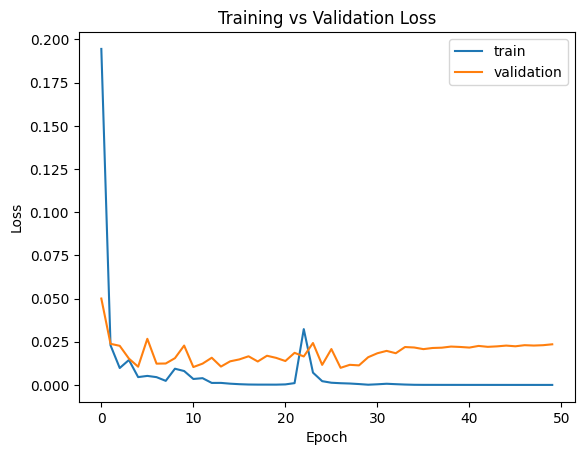

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_massif.history['loss'])
plt.plot(history_massif.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['train','validation'])
plt.show()

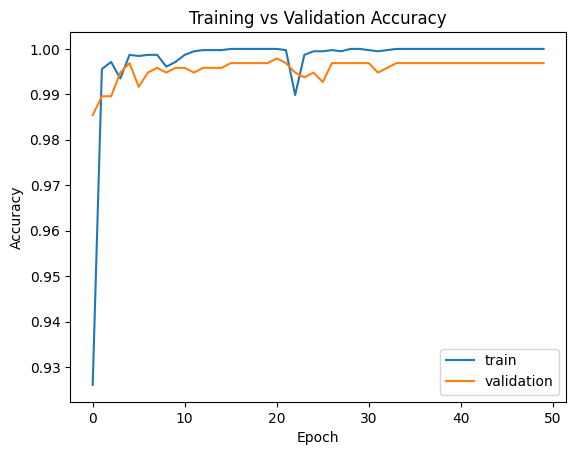

In [ ]:
plt.plot(history_massif.history['accuracy'])
plt.plot(history_massif.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['train','validation'])
plt.show()

In [ ]:
from tensorflow.keras.layers import Dropout, BatchNormalization

model_reg = Sequential()

model_reg.add(Dense(256, input_shape=(X_train.shape[1],)))
model_reg.add(BatchNormalization())
model_reg.add(Dense(256, activation='relu'))
model_reg.add(Dropout(0.5))

model_reg.add(Dense(256))
model_reg.add(BatchNormalization())
model_reg.add(Dense(256, activation='relu'))
model_reg.add(Dropout(0.5))

model_reg.add(Dense(256))
model_reg.add(BatchNormalization())
model_reg.add(Dense(256, activation='relu'))
model_reg.add(Dropout(0.5))

model_reg.add(Dense(3, activation='softmax'))

In [ ]:
model_reg.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_reg = model_reg.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9201 - loss: 0.2094 - val_accuracy: 0.9760 - val_loss: 0.0759
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9732 - loss: 0.0793 - val_accuracy: 0.9927 - val_loss: 0.0200
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9794 - loss: 0.0635 - val_accuracy: 0.9812 - val_loss: 0.0407
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9849 - loss: 0.0416 - val_accuracy: 0.9896 - val_loss: 0.0252
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9839 - loss: 0.0475 - val_accuracy: 0.9958 - val_loss: 0.0108
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9870 - loss: 0.0397 - val_accuracy: 0.9958 - val_loss: 0.0106
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9812 - loss: 0.0529 - val_accuracy: 0.9969 - val_loss: 0.0135
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9904 - loss: 0.0283 - val_accuracy: 0.9927 - v

In [ ]:
print("Massif model test:")
model_massif.evaluate(X_test, y_test)

print("Regularized model test:")
model_reg.evaluate(X_test, y_test)

Massif model test:
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9983 - loss: 0.0024    
Regularized model test:
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9992 - loss: 0.0029


[0.002937398850917816, 0.9991666674613953]

In [ ]:
from tensorflow.keras.optimizers import Adam

model_high_lr = model_reg

model_high_lr.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_high = model_high_lr.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9690 - loss: 0.1801 - val_accuracy: 0.8479 - val_loss: 5.4103
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9688 - loss: 0.1358 - val_accuracy: 0.8885 - val_loss: 3.2026
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9651 - loss: 0.1641 - val_accuracy: 0.9927 - val_loss: 0.4311
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9693 - loss: 0.1171 - val_accuracy: 0.9854 - val_loss: 0.1225
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9805 - loss: 0.0900 - val_accuracy: 0.9927 - val_loss: 0.2168
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9750 - loss: 0.0995 - val_accuracy: 0.9802 - val_loss: 0.5392
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9815 - loss: 0.0530 - val_accuracy: 0.9979 - val_loss: 0.0040
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9828 - loss: 0.0644 - val_accuracy: 0.9823 - v

In [ ]:
model_low_lr = model_reg

model_low_lr.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_low = model_low_lr.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9849 - loss: 0.0479 - val_accuracy: 0.9969 - val_loss: 0.0055
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9911 - loss: 0.0256 - val_accuracy: 0.9969 - val_loss: 0.0053
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9904 - loss: 0.0267 - val_accuracy: 0.9969 - val_loss: 0.0052
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9951 - loss: 0.0181 - val_accuracy: 0.9969 - val_loss: 0.0051
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9927 - loss: 0.0247 - val_accuracy: 0.9969 - val_loss: 0.0051
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9932 - loss: 0.0239 - val_accuracy: 0.9969 - val_loss: 0.0053
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9937 - loss: 0.0197 - val_accuracy: 0.9969 - val_loss: 0.0051
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9953 - loss: 0.0158 - val_accuracy: 0.9969 - v

Le surapprentissage apparaît lorsque le modèle apprend trop bien les données d’entraînement mais généralise mal sur de nouvelles données. Dans un système IoT de maintenance prédictive, cela peut provoquer des faux positifs ou des faux négatifs.
Le modèle régularisé avec Dropout et Batch Normalization réduit l’overfitting et améliore la capacité de généralisation.
Concernant le learning rate, une valeur trop élevée rend l’apprentissage instable tandis qu’une valeur trop faible ralentit la convergence.
Pour une utilisation industrielle, un modèle régularisé avec un learning rate modéré est recommandé.